In [ ]:
################################################################################
# S&P 500 Index Prediction Using a Hybrid ARFIMA-LSTM Model with Wavelet Decomposition Project
#  Ahmet Kaçmaz

<p align="center">
  <img src="1_QRu9hDVzyXIL3P0VTPlw3g.jpg" width="80%">
</p>

In [1]:
pip install statsmodels yfinance pandas numpy tensorflow scikit-learn ta pmdarima arch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 28.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 985.1/985.1 kB 53.5 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=372a5e67246265866f5977fe1c0b2bea2b1b624ec2808e2f75922238f730af20
  Stored in directory: /root/.cache/pip/wheels/5f/67/4f/8a9f252836e053e532c6587a3230bc72a4deb16b03a829610b
Successfully built ta
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pywt
from arch import arch_model
import pmdarima as pm
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from scipy.optimize import minimize

In [6]:
# Download historical data for S&P 500
ticker = '^GSPC'  # S&P 500 index symbol in Yahoo Finance
data = yf.download(ticker, start='2010-01-01', end='2023-12-31')


[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed


Creating the model...

Training the model...
Training ARFIMA model...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-17375.804, Time=0.11 sec


 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-17438.915, Time=0.13 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-17428.652, Time=0.15 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-17457.803, Time=0.26 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=-17455.841, Time=0.48 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-17455.788, Time=0.51 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-17447.952, Time=0.21 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=-17453.917, Time=1.11 sec
 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=-17460.988, Time=0.63 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-17443.052, Time=0.31 sec
 ARIMA(3,0,0)(0,0,0)[0] intercept   : AIC=-17459.072, Time=1.51 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=-17458.955, Time=0.74 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-17451.820, Time=0.39 sec
 ARIMA(3,0,1)(0,0,0)[0] intercept   : AIC=-17457.194, Time=0.93 sec

Best model:  ARIMA(2,0,0)(0,0,0)[0] intercept
Total fit time: 7.468 seconds
Calculating ARFIMA residuals...
Perform

<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is dep

Training LSTM model...
Epoch 1/150


...

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - loss: 1.0580 - val_loss: 1.4945e-04 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.1061 - val_loss: 1.8272e-04 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.8531 - val_loss: 1.4866e-04 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7484 - val_loss: 2.2852e-04 - learning_rate: 0.0010
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.7976 - val_loss: 3.3496e-04 - learning_rate: 0.0010
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.5224 - val_loss: 4.2471e-04 - learning_rate: 0.0010
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.7253 - val_loss: 9.0816e-04 - learning_rate: 1.0000e-04
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.5063 - val_loss: 0.0015 - learning_rate: 1.0000e-04
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4623 - val_loss: 0.0021 - learning_rate: 1.0000e-04

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 2.0243 - val_loss: 1.4925e-04 - learning_rate: 0.0010
Epoch 2/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 1.3539 - val_loss: 1.5383e-04 - learning_rate: 0.0010
Epoch 3/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8844 - val_loss: 1.8749e-04 - learning_rate: 0.0010
Epoch 4/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.9016 - val_loss: 2.5852e-04 - learning_rate: 0.0010
Epoch 5/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.7741 - val_loss: 2.2796e-04 - learning_rate: 0.0010
Epoch 6/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8038 - val_loss: 2.6454e-04 - learning_rate: 0.0010
Epoch 7/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.6176 - val_loss: 1.9307e-04 - learning_rate: 1.0000e-04
Epoch 8/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8791 - val_loss: 1.6234e-04 - learning_rate: 1.0000e-04
Epoch 9/150
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.8191 - val_loss: 1.5689e-04 - learning_rate: 1.

/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-16-49f447811202>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-16-49f447811202>:73: FutureWar

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

Model Performance:
MSE: 0.000011
RMSE: 0.003342
MAE: 0.002741
R2: 0.820756
DIRECTION_ACCURACY: 0.948718
MAPE: 67.907056


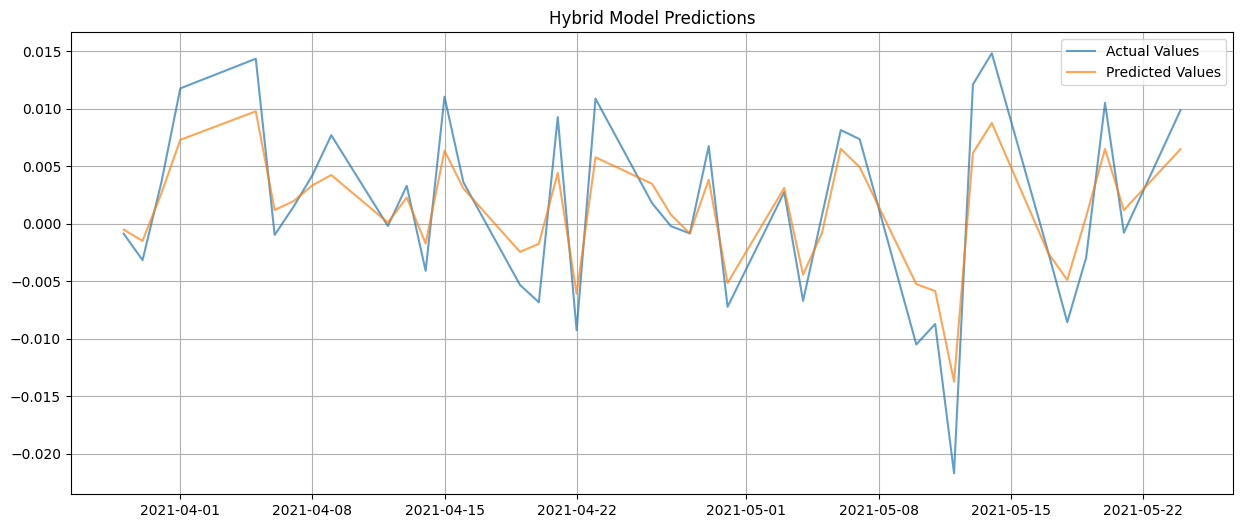

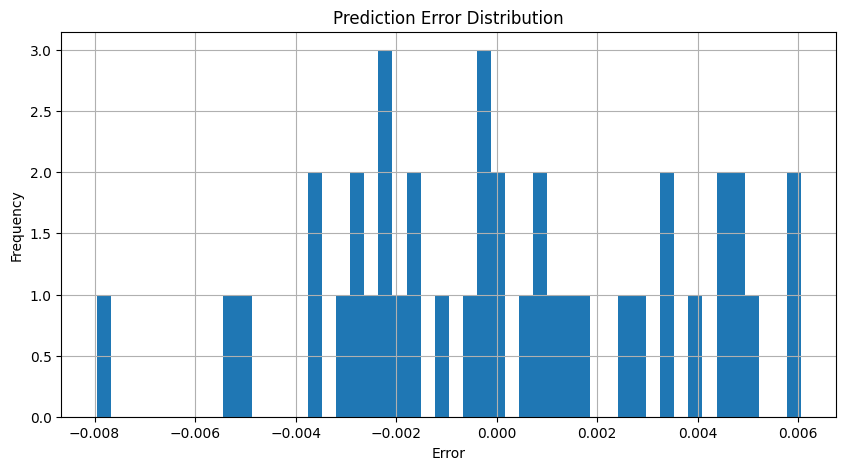


Additional Analysis:
Mean Error: 0.000183
Error Std: 0.003337
Min Error: -0.007962
Max Error: 0.006054

Directional Prediction Details:
Correct Direction Predictions: 37/39 (94.87%)


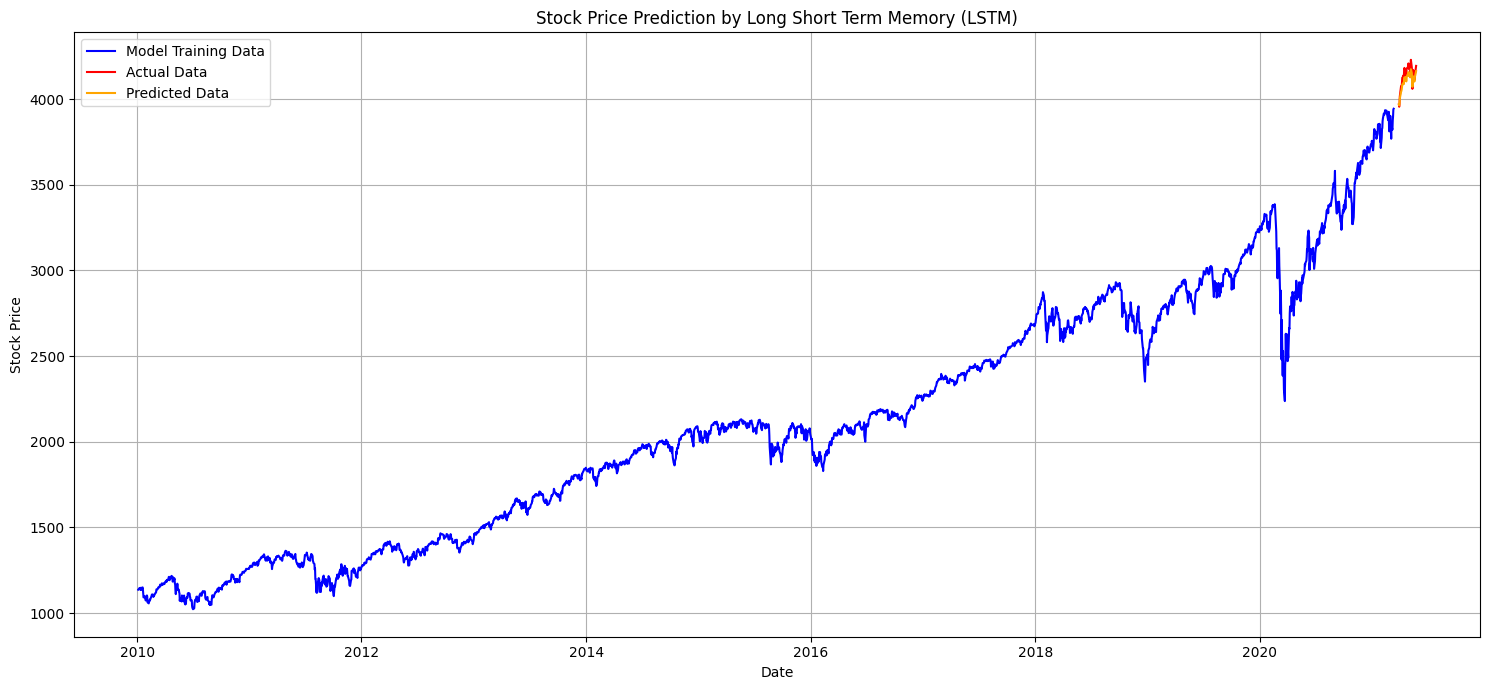


Price Prediction Performance:
Price MSE: 1187.38
Price RMSE: 34.46
Price MAE: 31.37
Price R2: 0.7180

Log Scale Prediction Performance:
Log MSE: 0.00001117
Log RMSE: 0.00334225
Log MAE: 0.00274094
Log R2: 0.8208


In [16]:
# Import necessary libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pywt
from xgboost import XGBRegressor
import pmdarima as pm
from scipy import stats
import tensorflow as tf

# Function to download stock data and calculate log returns
def get_data():
    sp500 = yf.download('^GSPC', start='2010-01-01', end='2024-01-01')
    sp500['Log_Returns'] = np.log(sp500['Close'] / sp500['Close'].shift(1))  # Calculate log returns
    sp500 = sp500.dropna()  # Drop missing values
    return sp500

# Hybrid model class combining ARFIMA, LSTM, and Random Forest
class ImprovedHybridModel:
    def __init__(self, seq_length=10):
        self.seq_length = seq_length
        self.arfima_model = None
        self.lstm_model = None
        self.rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0)
        self.scaler = StandardScaler()
        self.history = None
        self.detail_models = []

    # Wavelet decomposition into approximation and detail coefficients
    def decompose_with_awt(self, data):
        """Decompose the data into approximate and detail components using AWD."""
        wavelet = 'db4'
        level = 4
        data = np.asarray(data)
        coeffs = pywt.wavedec(data, wavelet, level=level)  # Perform wavelet decomposition
        approx = coeffs[0]  # Approximation component
        details = coeffs[1:]  # Detail components
        return approx, details

    # Reconstruct the signal from wavelet components
    def reconstruct_signal(self, approx, details):
        """Reconstruct signal from AWD components."""
        coeffs = [approx] + list(details)
        return pywt.waverec(coeffs, 'db4')  # Perform wavelet reconstruction

    # Prepare sequences for LSTM input
    def prepare_sequences(self, data, features=None):
        """Prepare sequences for LSTM input."""
        if isinstance(data, pd.Series):
            data = data.values.reshape(-1, 1)

        df = pd.DataFrame(data, columns=['returns'])

        # Calculate volatility as a rolling standard deviation
        df['volatility'] = df['returns'].rolling(window=10).std()

        # Calculate momentum as a rolling mean
        df['momentum'] = df['returns'].rolling(window=5).mean()

        # Add lagged values
        for i in range(1, 4):
            df[f'lag_{i}'] = df['returns'].shift(i)

        # Fill missing values
        df = df.fillna(method='bfill').fillna(method='ffill')

        # Generate sequences of fixed length
        sequences = []
        for i in range(len(df) - self.seq_length):
            sequences.append(df.iloc[i:(i + self.seq_length)].values)

        return np.array(sequences)

    # Create LSTM model architecture
    def create_lstm_model(self, input_shape):
        """Create the LSTM model."""
        model = Sequential([
            LSTM(32, input_shape=(input_shape[0], input_shape[1]), return_sequences=True),
            BatchNormalization(),
            Dropout(0.3),

            LSTM(16),
            BatchNormalization(),
            Dropout(0.3),

            Dense(32, activation='relu'),
            BatchNormalization(),
            Dense(16, activation='gelu'),
            BatchNormalization(),

            Dense(1)
        ])

        optimizer = Adam(learning_rate=0.001)
        model.compile(optimizer=optimizer, loss='mse')  # Compile the model with Mean Squared Error loss
        return model

    # Combine predictions using Random Forest
    def combine_predictions(self, approx_pred, detail_preds, y_true):
        """Combine predictions using Random Forest."""
        min_length = min(len(approx_pred), len(y_true))
        min_length = min(min_length, min(len(d) for d in detail_preds))

        approx_pred = approx_pred[:min_length]
        detail_preds = [d[:min_length] for d in detail_preds]
        y_true = y_true[:min_length]

        X = np.column_stack([approx_pred] + detail_preds)
        self.rf_model.fit(X, y_true)  # Train Random Forest on combined predictions
        return self.rf_model.predict(X)

    # Train the hybrid model
    def fit(self, data):
        """Fit the hybrid model."""
        print("Training ARFIMA model...")
        # Automatically select the best ARFIMA parameters
        self.arfima_model = pm.auto_arima(
            data,
            start_p=0, start_q=0,
            max_p=3, max_q=3,
            m=1,  # Non-seasonal model
            d=None,
            seasonal=False,
            trace=True,  # Print model search process
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True  # Use stepwise search
        )

        print("Calculating ARFIMA residuals...")
        # Get ARFIMA in-sample predictions and calculate residuals
        arfima_predictions = self.arfima_model.predict_in_sample(data)
        residuals = data - arfima_predictions

        print("Performing Wavelet decomposition...")
        # Decompose the residuals into approximation and detail components
        approx, details = self.decompose_with_awt(residuals)

        print("Preparing data for LSTM...")
        # Prepare sequences for LSTM using approximation component
        X_approx = self.prepare_sequences(pd.Series(approx))
        # Prepare sequences for LSTM using detail components
        X_details = [self.prepare_sequences(pd.Series(d)) for d in details]
        y = pd.Series(residuals)[self.seq_length:]  # Target values for training

        # Ensure all sequences and target values are of equal length
        min_length = min(len(X_approx), len(X_details[0]))
        X_approx = X_approx[:min_length]
        X_details = [X_d[:min_length] for X_d in X_details]
        y = y[:min_length]

        # Split data into training and validation sets
        train_size = int(len(X_approx) * 0.7)  # 70% for training
        val_size = int(len(X_approx) * 0.15)  # 15% for validation

        X_train_approx = X_approx[:train_size]
        y_train = y[:train_size]
        X_val_approx = X_approx[train_size:train_size + val_size]
        y_val = y[train_size:train_size + val_size]

        print("Training LSTM model...")
        # Create and train the LSTM model on approximation component
        self.lstm_model = self.create_lstm_model((X_approx.shape[1], X_approx.shape[2]))
        callbacks = [
            EarlyStopping(
                monitor='val_loss',  # Stop training when validation loss stops improving
                patience=10,  # Wait 10 epochs before stopping
                restore_best_weights=True,  # Restore best model weights
                min_delta=0.0001  # Minimum change in loss to qualify as improvement
            ),
            ReduceLROnPlateau(
                monitor='val_loss',  # Reduce learning rate when validation loss plateaus
                factor=0.1,  # Reduce learning rate by a factor of 10
                patience=5,  # Wait 5 epochs before reducing learning rate
                min_lr=0.00001,  # Minimum learning rate
                min_delta=0.0001  # Minimum change in loss
            )
        ]

        history_approx = self.lstm_model.fit(
            X_train_approx, y_train,
            epochs=150,  # Maximum number of epochs
            batch_size=32,  # Batch size
            validation_data=(X_val_approx, y_val),  # Validation data
            callbacks=callbacks,  # Early stopping and learning rate scheduler
            shuffle=True,  # Shuffle training data
            verbose=1  # Print training progress
        )

        # Train LSTM models on each detail component
        self.detail_models = []
        detail_predictions = []
        for i, X_detail in enumerate(X_details):
            print(f"Training detail component {i + 1}...")
            X_train_detail = X_detail[:train_size]
            X_val_detail = X_detail[train_size:train_size + val_size]

            detail_model = self.create_lstm_model((X_detail.shape[1], X_detail.shape[2]))
            history_detail = detail_model.fit(
                X_train_detail, y_train,
                epochs=150,
                batch_size=32,
                validation_data=(X_val_detail, y_val),
                callbacks=callbacks,
                shuffle=True,
                verbose=1
            )
            self.detail_models.append(detail_model)
            detail_predictions.append(detail_model.predict(X_detail))

        # Combine predictions from approximation and detail models
        approx_pred = self.lstm_model.predict(X_approx)
        final_predictions = self.combine_predictions(approx_pred, detail_predictions, y)

        # Save training history
        self.history = history_approx.history
        return self

    def predict(self, data):
        """Make predictions using the trained model."""
        if isinstance(data, pd.Series):
            data = data.values

        # Generate ARFIMA predictions
        arfima_pred = self.arfima_model.predict(len(data))
        residuals = data - arfima_pred

        # Decompose residuals using Wavelet decomposition
        approx, details = self.decompose_with_awt(residuals)

        # Prepare sequences for LSTM predictions
        X_approx = self.prepare_sequences(pd.Series(approx))
        X_details = [self.prepare_sequences(pd.Series(d)) for d in details]

        # Ensure sequences are of equal length
        min_length = min(len(X_approx), min(len(X_d) for X_d in X_details))
        X_approx = X_approx[:min_length]
        X_details = [X_d[:min_length] for X_d in X_details]

        # Generate LSTM predictions for approximation component
        approx_pred = self.lstm_model.predict(X_approx)
        # Generate LSTM predictions for each detail component
        detail_preds = [detail_model.predict(X_detail) for detail_model, X_detail in zip(self.detail_models, X_details)]

        # Combine all predictions
        final_predictions = self.combine_predictions(
            approx_pred,
            detail_preds,
            residuals[self.seq_length:min_length + self.seq_length]
        )

        # Adjust predictions to original ARFIMA scale
        start_idx = self.seq_length
        end_idx = min(len(arfima_pred), start_idx + len(final_predictions))
        final_predictions = (arfima_pred[start_idx:end_idx] +
                             final_predictions[:end_idx - start_idx])

        return final_predictions

    def evaluate(self, y_true, y_pred):
        """Evaluate model performance using various metrics."""
        results = {
            'mse': mean_squared_error(y_true, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
            'mae': mean_absolute_error(y_true, y_pred),
            'r2': r2_score(y_true, y_pred)
        }

        # Directional accuracy
        true_direction = np.sign(np.diff(y_true))
        pred_direction = np.sign(np.diff(y_pred))
        results['direction_accuracy'] = np.mean(true_direction == pred_direction)

        # Mean Absolute Percentage Error (MAPE)
        results['mape'] = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        return results

    def plot_history(self):
        """Plot the training history of the LSTM model."""
        if self.history is None:
            print("No training history found!")
            return

        plt.figure(figsize=(12, 4))
        plt.plot(self.history['loss'], label='Training Loss')
        plt.plot(self.history['val_loss'], label='Validation Loss')
        plt.title('Model Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend()
        plt.grid(True)
        plt.show()


# Main code
print("Downloading data...")
data = get_data()

# Train-test split
train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

print("\nCreating the model...")
model = ImprovedHybridModel(seq_length=10)

print("\nTraining the model...")
model.fit(train_data['Log_Returns'])



# Make predictions
print("\nMaking predictions...")
predictions = model.predict(test_data['Log_Returns'])

# Prepare test data for evaluation
test_values = test_data['Log_Returns'].values[model.seq_length:model.seq_length + len(predictions)]

# Evaluate model performance
results = model.evaluate(test_values, predictions)

print("\nModel Performance:")
for metric, value in results.items():
    print(f"{metric.upper()}: {value:.6f}")

# Visualize predictions
plt.figure(figsize=(15, 6))
test_dates = test_data.index[model.seq_length:model.seq_length + len(predictions)]

plt.plot(test_dates, test_values, label='Actual Values', alpha=0.7)
plt.plot(test_dates, predictions, label='Predicted Values', alpha=0.7)
plt.title('Hybrid Model Predictions')
plt.legend()
plt.grid(True)
plt.show()

# Analyze prediction errors
plt.figure(figsize=(10, 5))
errors = test_values - predictions
plt.hist(errors, bins=50)
plt.title('Prediction Error Distribution')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Additional analysis
print("\nAdditional Analysis:")
print(f"Mean Error: {np.mean(errors):.6f}")
print(f"Error Std: {np.std(errors):.6f}")
print(f"Min Error: {np.min(errors):.6f}")
print(f"Max Error: {np.max(errors):.6f}")

# Directional prediction analysis
print("\nDirectional Prediction Details:")
true_dir = np.sign(np.diff(test_values))
pred_dir = np.sign(np.diff(predictions))
correct_dirs = np.sum(true_dir == pred_dir)
total_dirs = len(true_dir)
print(f"Correct Direction Predictions: {correct_dirs}/{total_dirs} ({correct_dirs / total_dirs * 100:.2f}%)")

# Convert predictions to original price scale
def convert_returns_to_prices(initial_price, returns):
    """Convert log returns back to price values."""
    prices = [initial_price]
    for ret in returns:
        prices.append(prices[-1] * np.exp(ret))
    return np.array(prices)

# Get the initial price from the test dataset
initial_price = test_data['Close'].iloc[model.seq_length]

# Convert actual and predicted returns to prices
actual_prices = convert_returns_to_prices(initial_price, test_values)
predicted_prices = convert_returns_to_prices(initial_price, predictions)

# Visualize price predictions
plt.figure(figsize=(15, 7))

# Training data
plt.plot(train_data.index, train_data['Close'], 
         label='Model Training Data', color='blue')

# Actual test data
plt.plot(test_dates, actual_prices[1:], 
         label='Actual Data', color='red')

# Predicted prices
plt.plot(test_dates, predicted_prices[1:], 
         label='Predicted Data', color='orange')

plt.title('Stock Price Prediction by Long Short Term Memory (LSTM)')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Calculate performance metrics for price scale
print("\nPrice Prediction Performance:")
price_mse = mean_squared_error(actual_prices[1:], predicted_prices[1:])
price_rmse = np.sqrt(price_mse)
price_mae = mean_absolute_error(actual_prices[1:], predicted_prices[1:])
price_r2 = r2_score(actual_prices[1:], predicted_prices[1:])

print(f"Price MSE: {price_mse:.2f}")
print(f"Price RMSE: {price_rmse:.2f}")
print(f"Price MAE: {price_mae:.2f}")
print(f"Price R2: {price_r2:.4f}")

# Calculate performance metrics for log scale
print("\nLog Scale Prediction Performance:")
log_mse = mean_squared_error(test_values, predictions)
log_rmse = np.sqrt(log_mse)
log_mae = mean_absolute_error(test_values, predictions)
log_r2 = r2_score(test_values, predictions)

print(f"Log MSE: {log_mse:.8f}")
print(f"Log RMSE: {log_rmse:.8f}")
print(f"Log MAE: {log_mae:.8f}")
print(f"Log R2: {log_r2:.4f}")





In [5]:
print(data.head())
print(data.tail())


                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2010-01-05  1132.660034  1136.630005  1129.660034  1136.520020  1136.520020   
2010-01-06  1135.709961  1139.189941  1133.949951  1137.140015  1137.140015   
2010-01-07  1136.270020  1142.459961  1131.319946  1141.689941  1141.689941   
2010-01-08  1140.520020  1145.390015  1136.219971  1144.979980  1144.979980   
2010-01-11  1145.959961  1149.739990  1142.020020  1146.979980  1146.979980   

                Volume  Log_Returns  
Date                                 
2010-01-05  2491020000     0.003111  
2010-01-06  4972660000     0.000545  
2010-01-07  5270680000     0.003993  
2010-01-08  4389590000     0.002878  
2010-01-11  4255780000     0.001745  
                   Open         High          Low        Close    Adj Close  \
Date                                                                          
2023-12-22  4753.91992

In [6]:
print(f"Training Data Range: {train_data.index[0]} to {train_data.index[-1]}")
print(f"Test Data Range: {test_data.index[0]} to {test_data.index[-1]}")

Training Data Range: 2010-01-05 00:00:00 to 2021-03-12 00:00:00
Test Data Range: 2021-03-15 00:00:00 to 2023-12-29 00:00:00



Analyzing AAPL...


[*********************100%***********************]  1 of 1 completed

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


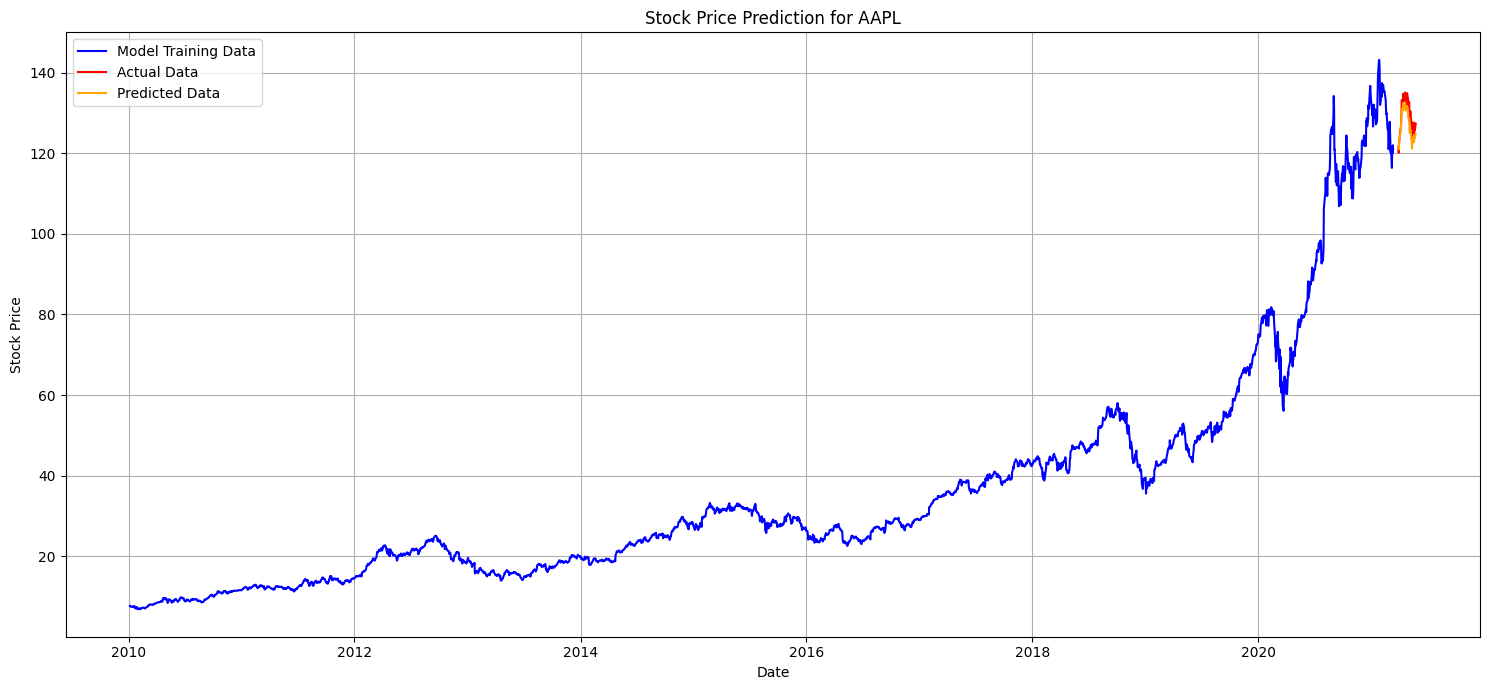

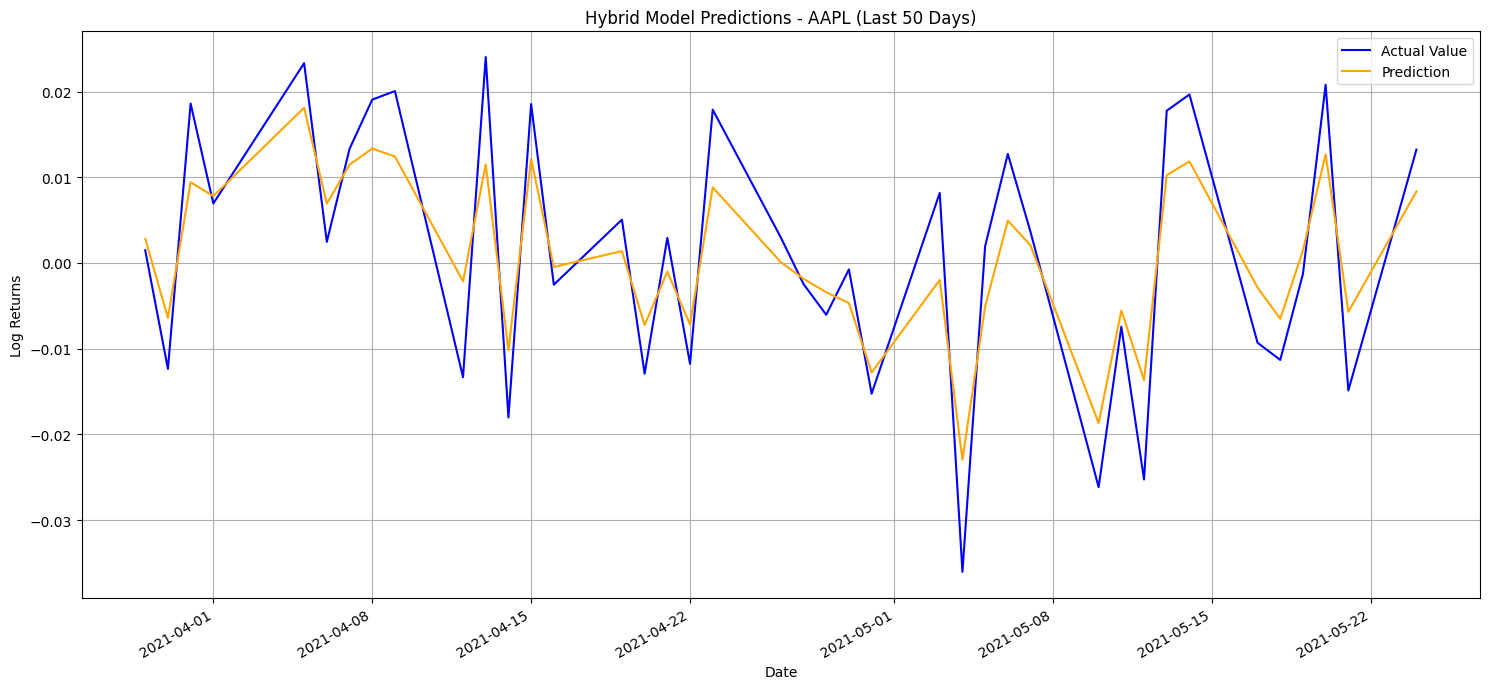


Performance Metrics for AAPL:
MSE: 0.000045
RMSE: 0.006703
MAE: 0.005842
R2: 0.800802
DIRECTION_ACCURACY: 0.948718
MAPE: 77.483497
Direction Accuracy (Last 50 days): 0.9487

Price Prediction Metrics for AAPL:
Price MSE: 6.45
Price RMSE: 2.54
Price MAE: 2.25
Price R2: 0.6469

Analyzing MSFT...


[*********************100%***********************]  1 of 1 completed

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


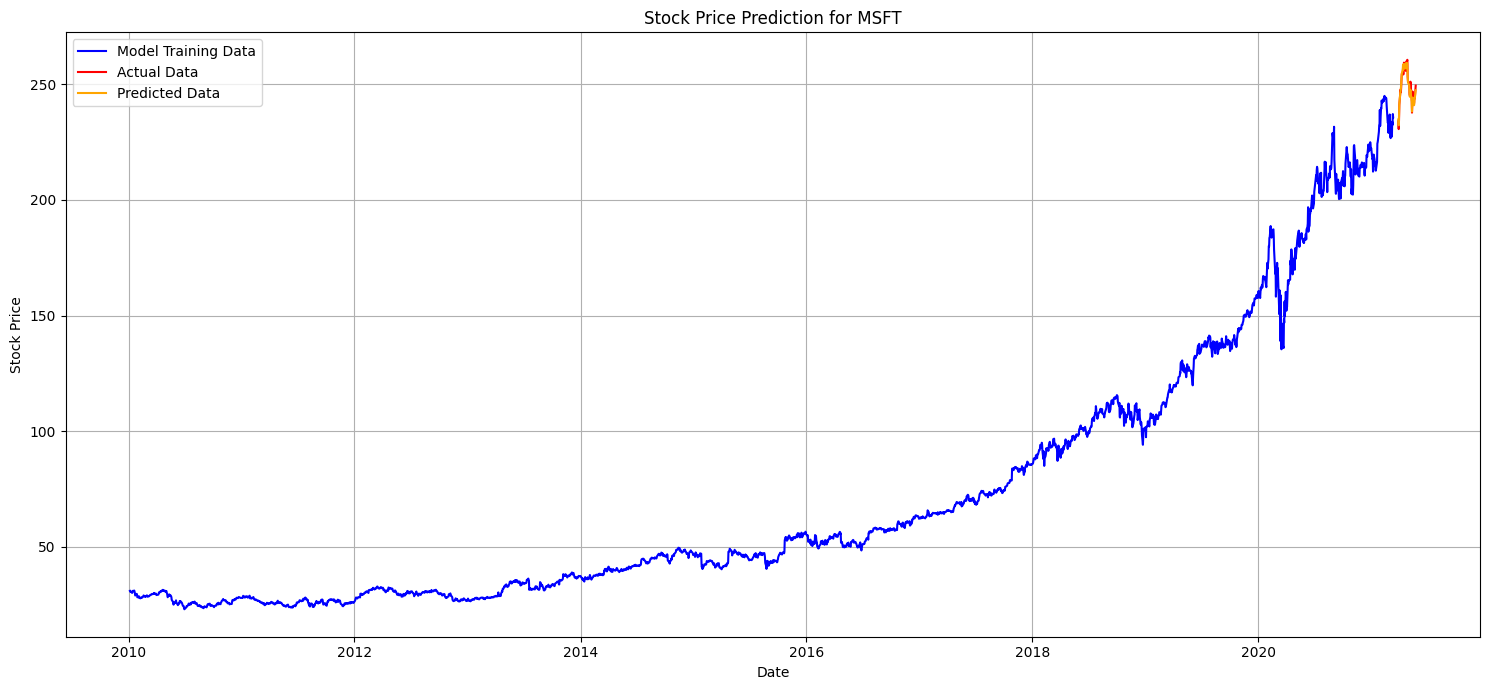

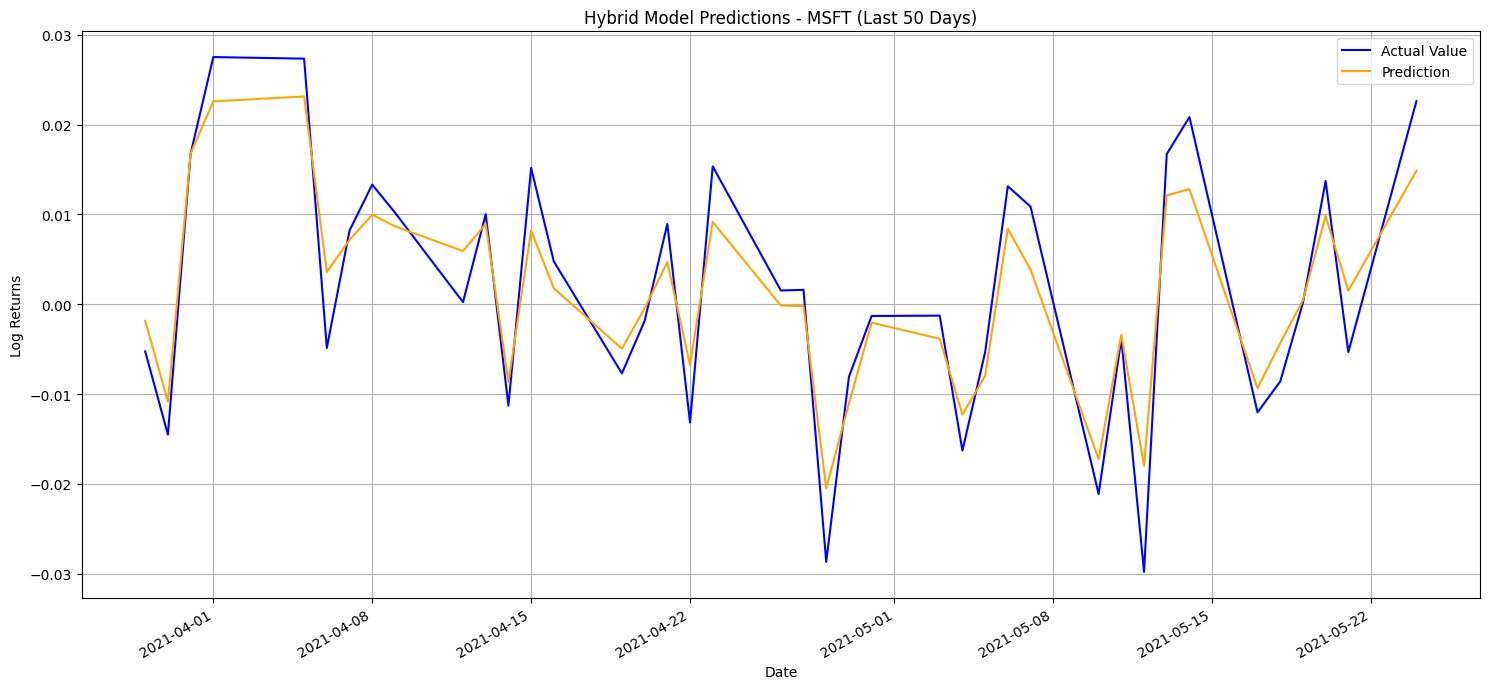

[*********************100%***********************]  1 of 1 completed


Performance Metrics for MSFT:
MSE: 0.000023
RMSE: 0.004820
MAE: 0.004044
R2: 0.881423
DIRECTION_ACCURACY: 0.923077
MAPE: 111.359931
Direction Accuracy (Last 50 days): 0.9231

Price Prediction Metrics for MSFT:
Price MSE: 1.83
Price RMSE: 1.35
Price MAE: 1.09
Price R2: 0.9680

Analyzing GOOGL...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


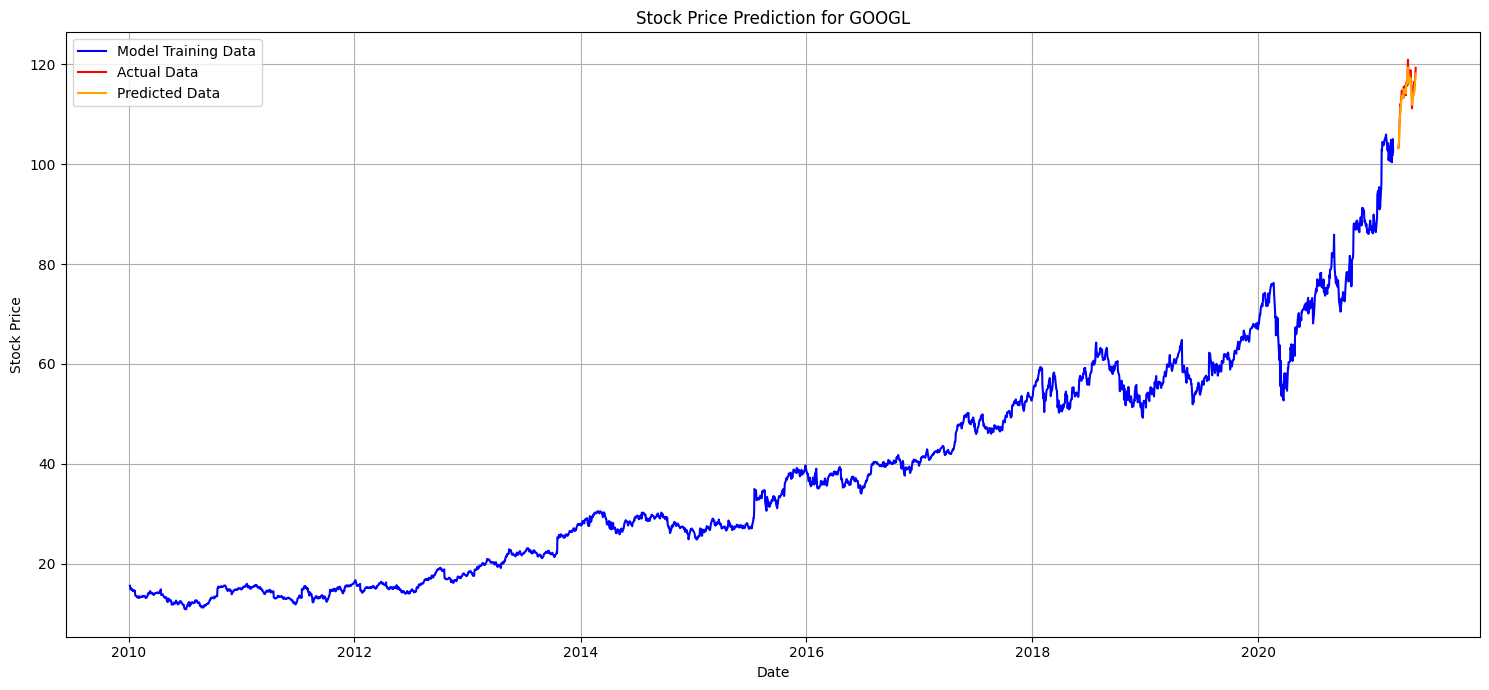

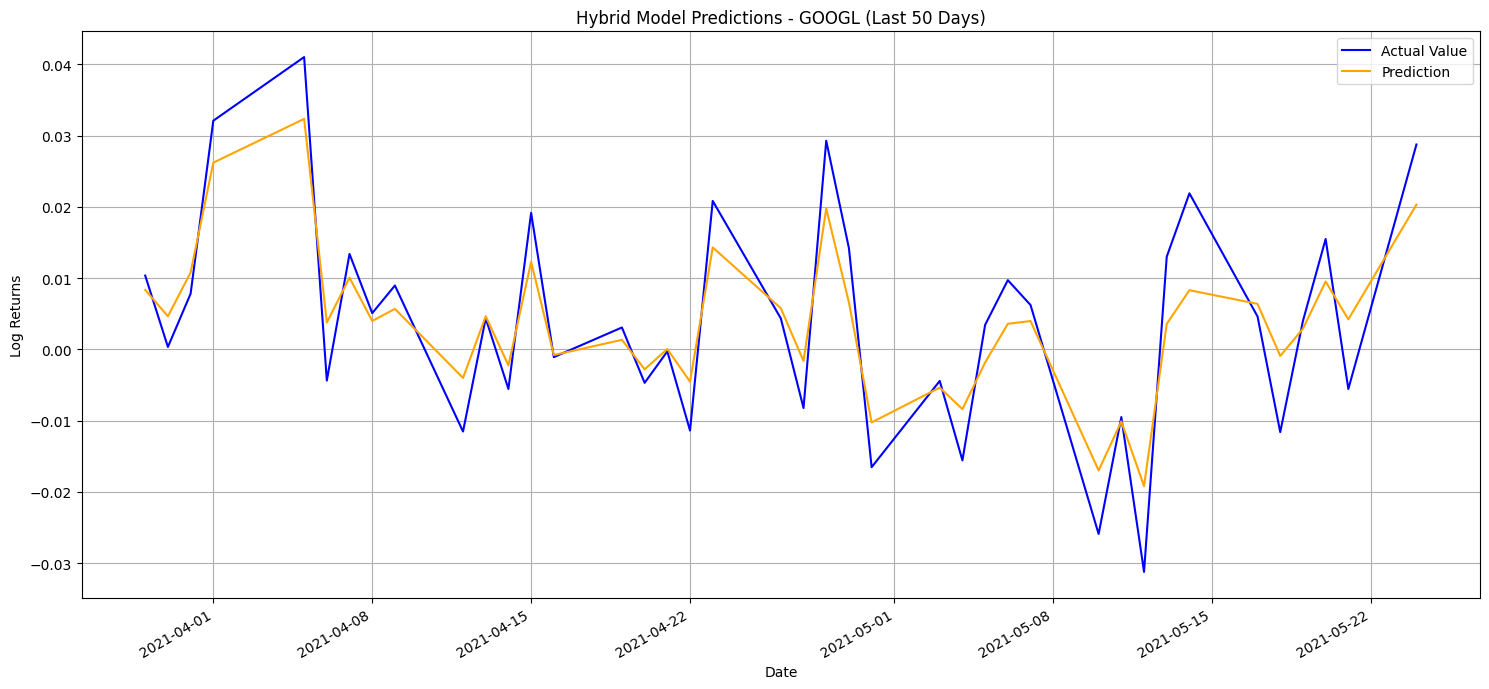

[*********************100%***********************]  1 of 1 completed


Performance Metrics for GOOGL:
MSE: 0.000040
RMSE: 0.006361
MAE: 0.005272
R2: 0.824537
DIRECTION_ACCURACY: 0.974359
MAPE: 83.219708
Direction Accuracy (Last 50 days): 0.9744

Price Prediction Metrics for GOOGL:
Price MSE: 0.63
Price RMSE: 0.79
Price MAE: 0.64
Price R2: 0.9594

Analyzing AMZN...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


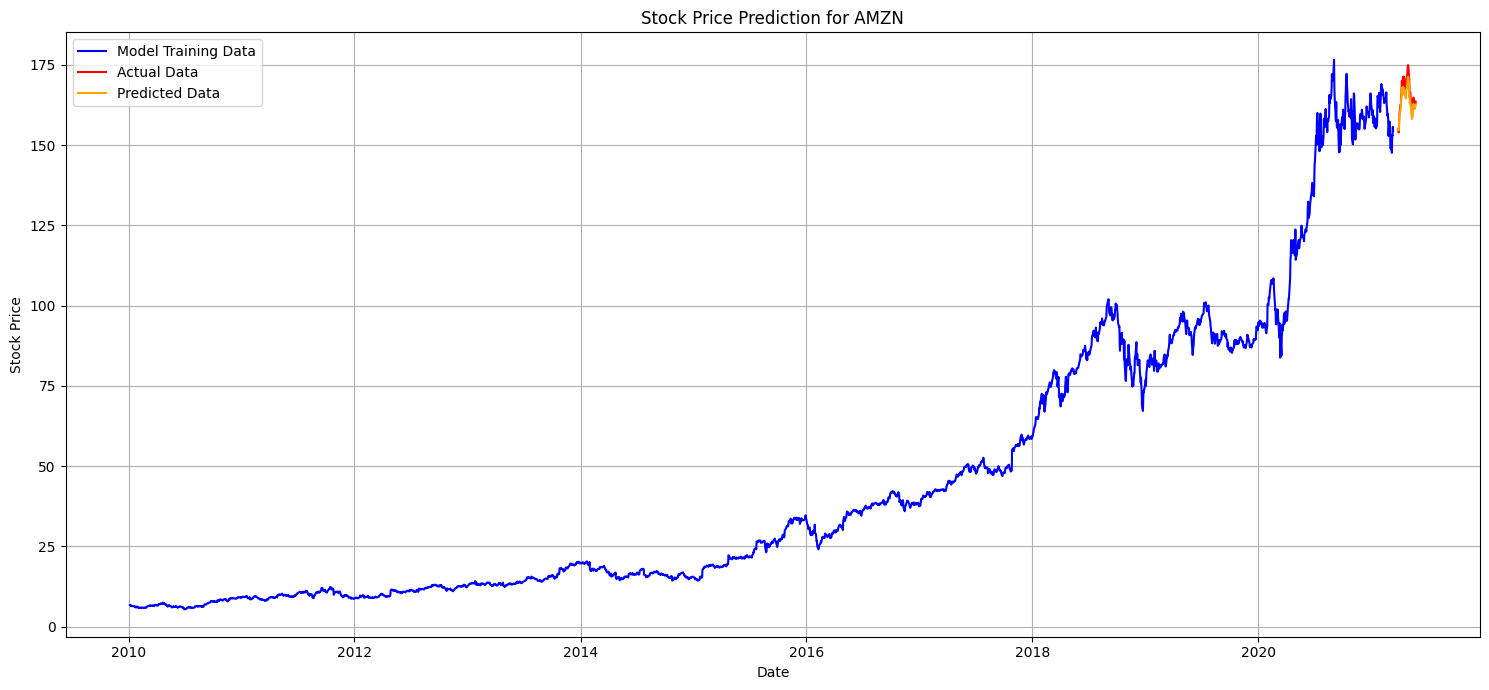

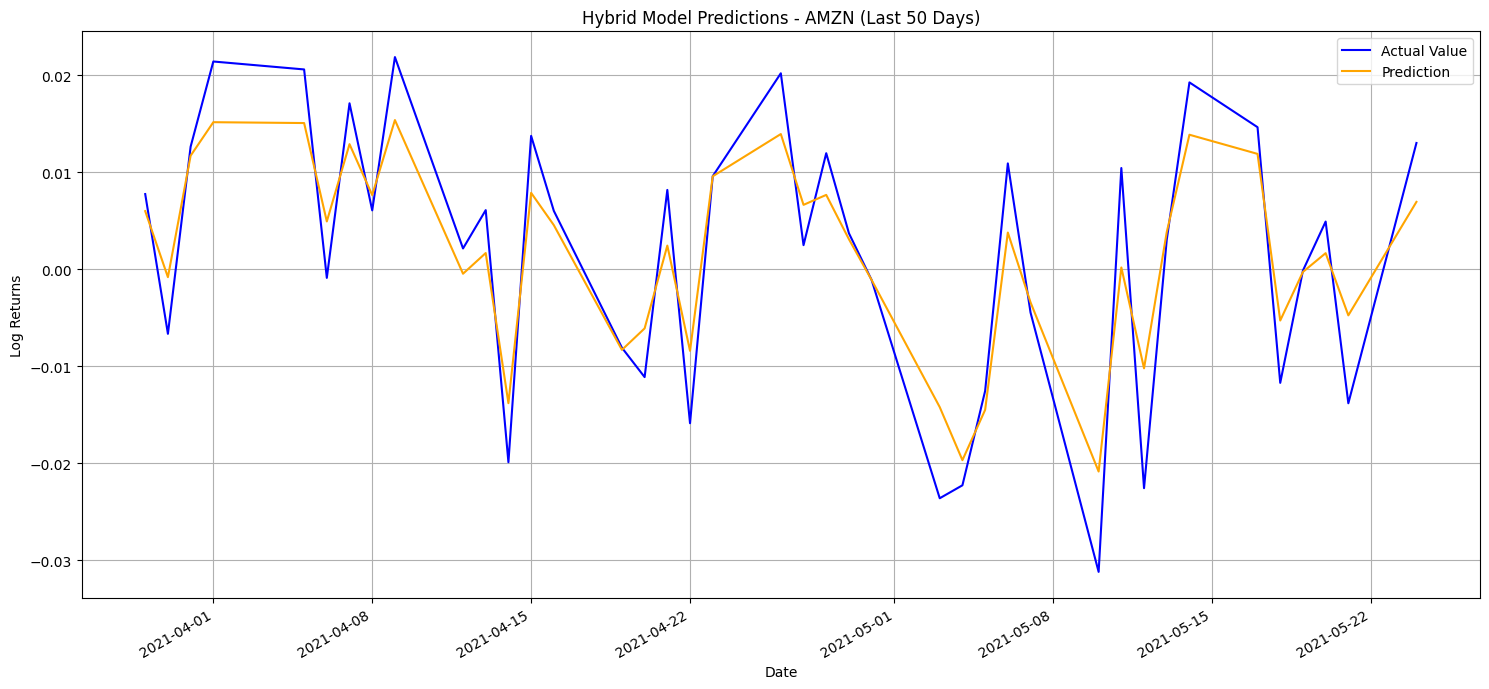

[*********************100%***********************]  1 of 1 completed


Performance Metrics for AMZN:
MSE: 0.000030
RMSE: 0.005515
MAE: 0.004540
R2: 0.843018
DIRECTION_ACCURACY: 0.948718
MAPE: 58.764970
Direction Accuracy (Last 50 days): 0.9487

Price Prediction Metrics for AMZN:
Price MSE: 4.86
Price RMSE: 2.20
Price MAE: 1.91
Price R2: 0.8246

Analyzing ^DJI...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


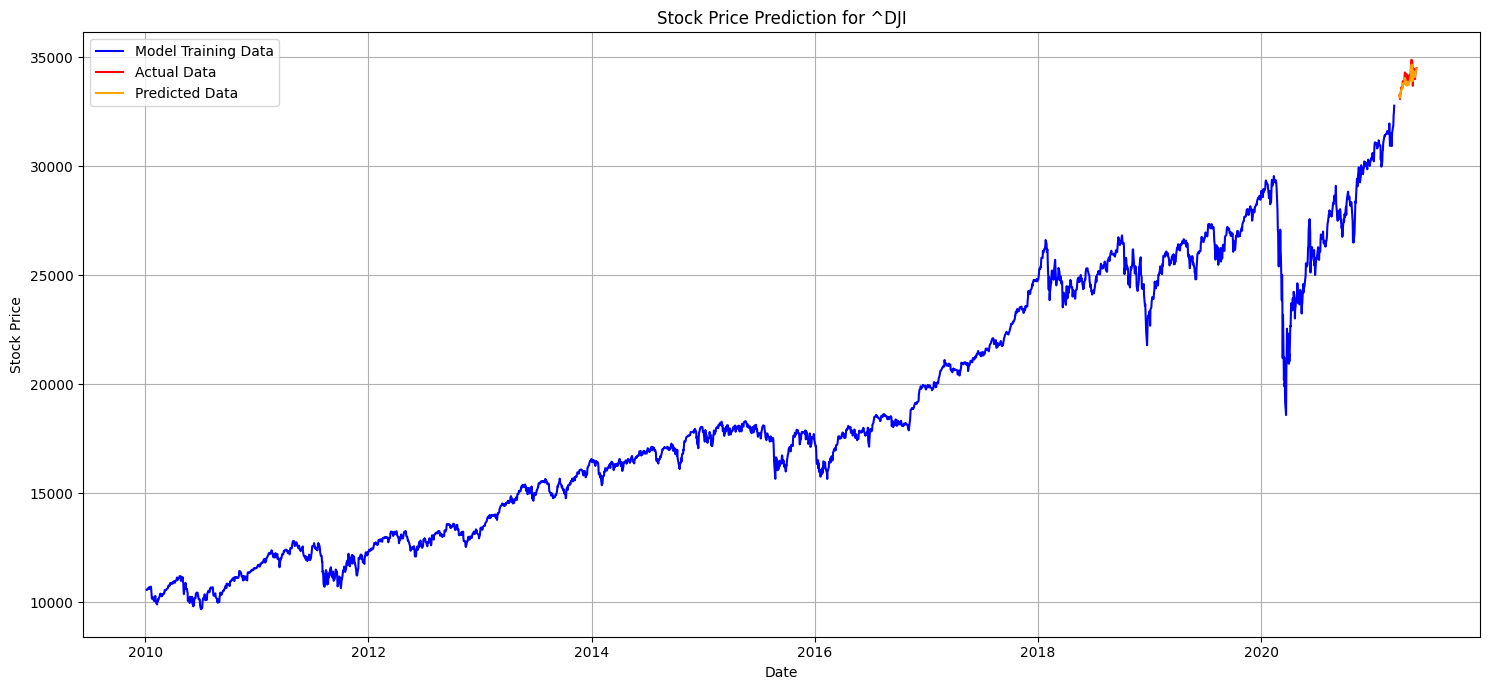

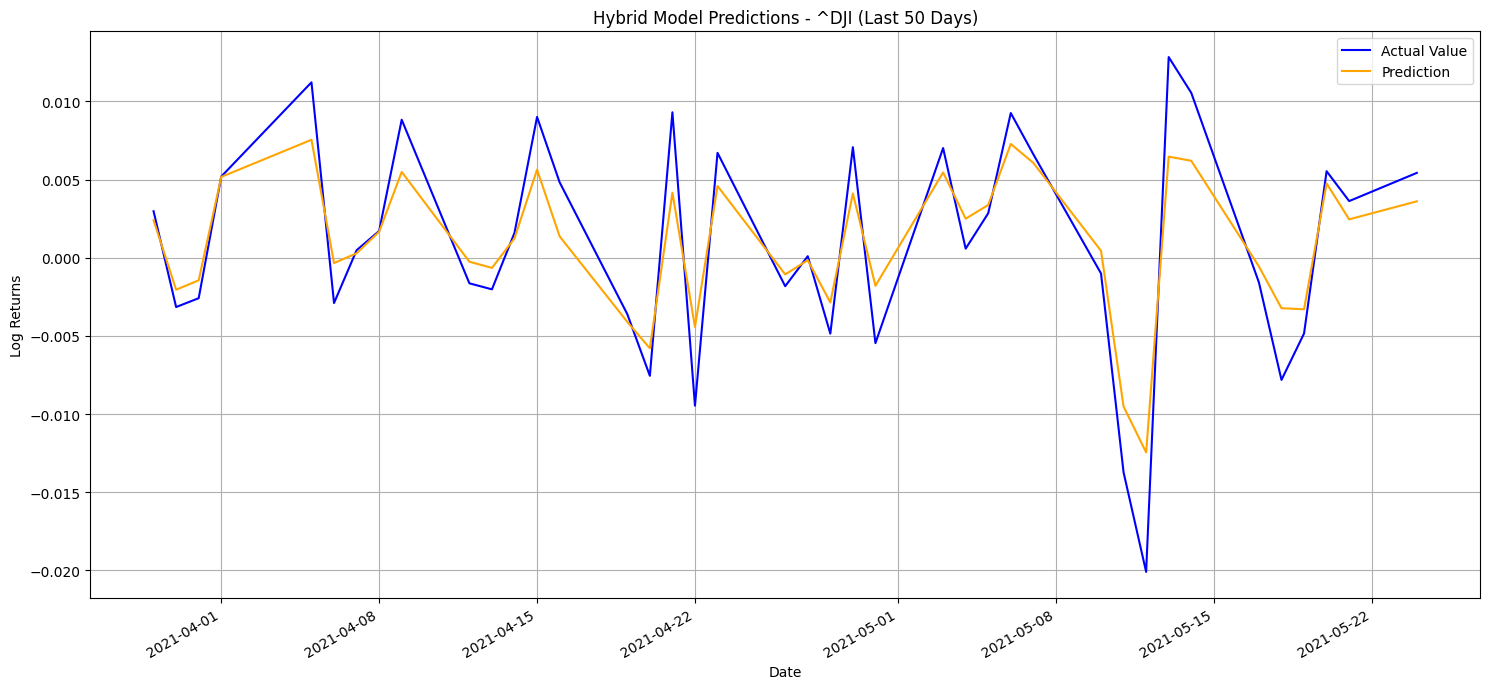

[*********************100%***********************]  1 of 1 completed


Performance Metrics for ^DJI:
MSE: 0.000008
RMSE: 0.002854
MAE: 0.002206
R2: 0.833503
DIRECTION_ACCURACY: 0.974359
MAPE: 53.837600
Direction Accuracy (Last 50 days): 0.9744

Price Prediction Metrics for ^DJI:
Price MSE: 28870.91
Price RMSE: 169.91
Price MAE: 135.19
Price R2: 0.8334

Analyzing ^IXIC...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


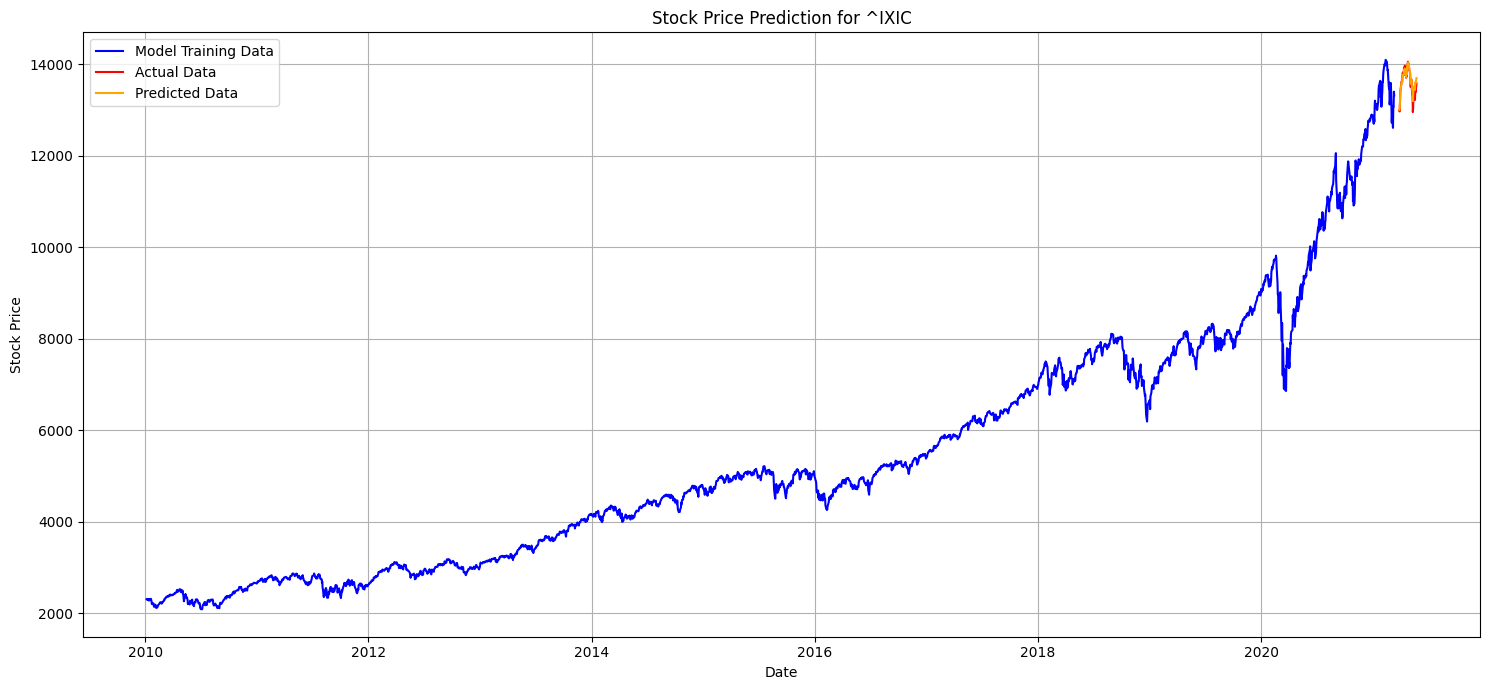

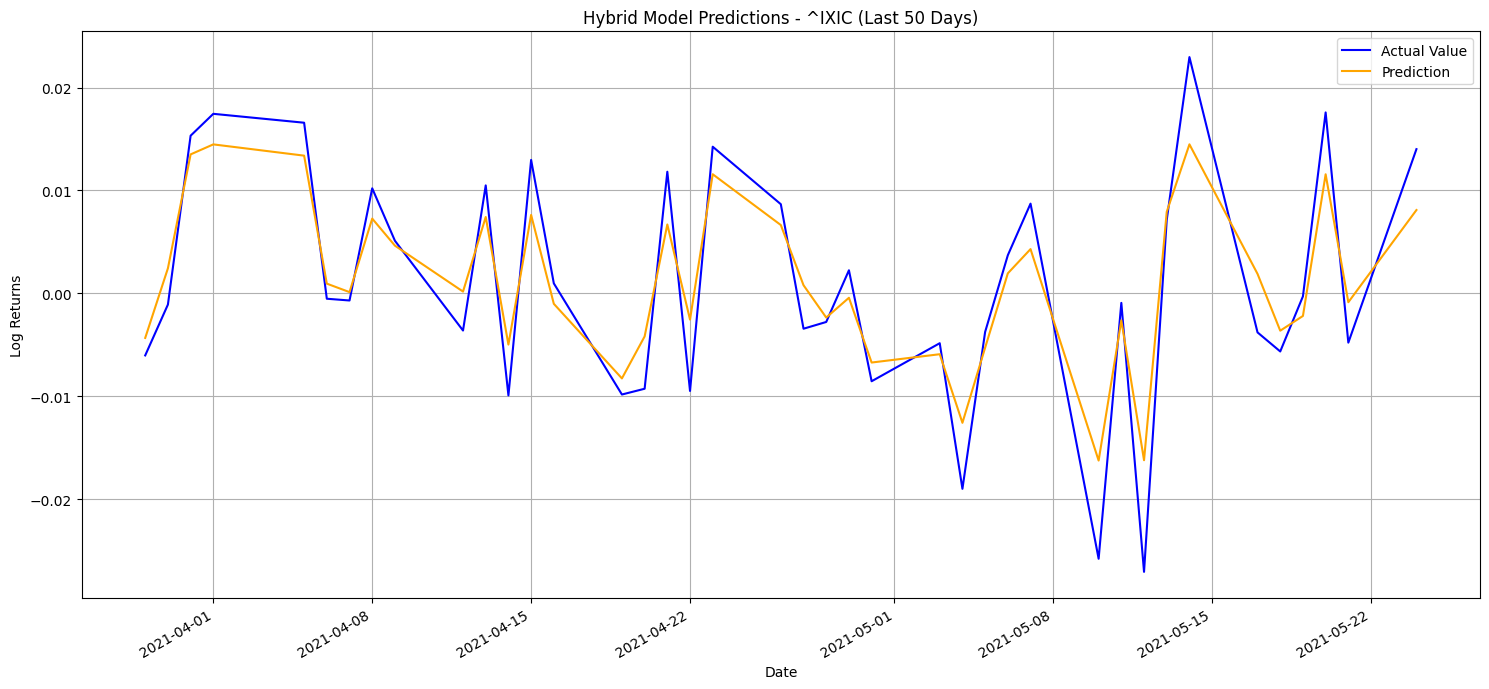

[*********************100%***********************]  1 of 1 completed


Performance Metrics for ^IXIC:
MSE: 0.000019
RMSE: 0.004334
MAE: 0.003567
R2: 0.854638
DIRECTION_ACCURACY: 0.974359
MAPE: 81.745696
Direction Accuracy (Last 50 days): 0.9744

Price Prediction Metrics for ^IXIC:
Price MSE: 11210.64
Price RMSE: 105.88
Price MAE: 75.92
Price R2: 0.8865

Analyzing ^FTSE...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


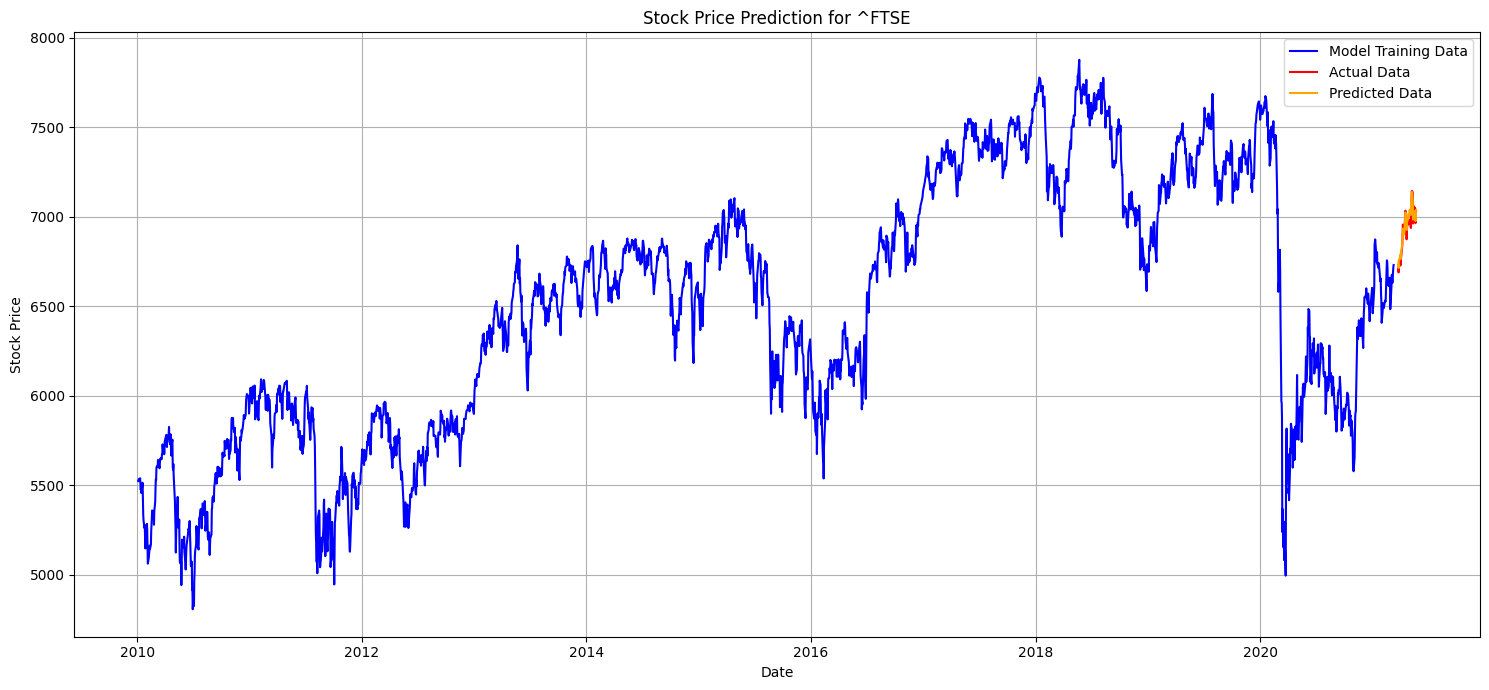

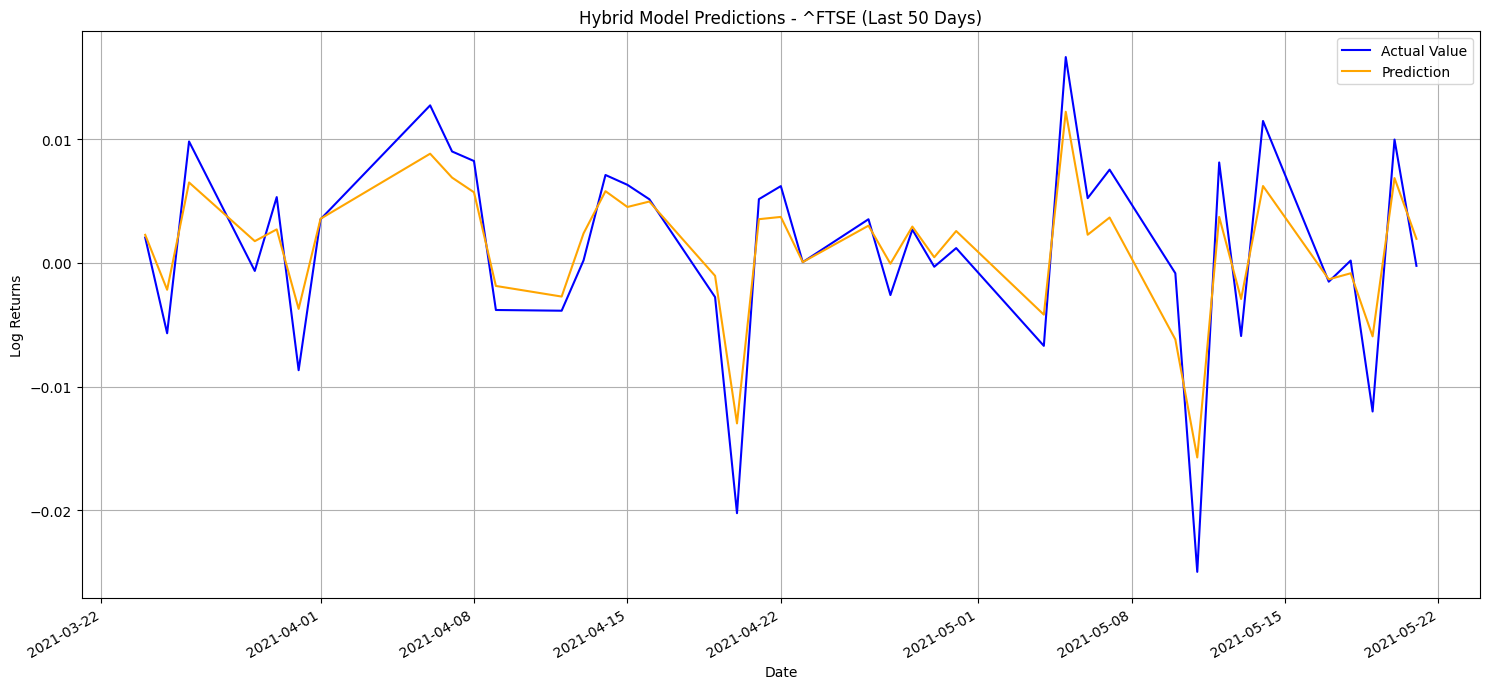

[*********************100%***********************]  1 of 1 completed


Performance Metrics for ^FTSE:
MSE: 0.000011
RMSE: 0.003343
MAE: 0.002657
R2: 0.832547
DIRECTION_ACCURACY: 0.974359
MAPE: 126.791534
Direction Accuracy (Last 50 days): 0.9744

Price Prediction Metrics for ^FTSE:
Price MSE: 792.46
Price RMSE: 28.15
Price MAE: 22.20
Price R2: 0.9377

Analyzing ^N225...
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 



/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill').fillna(method='ffill')
<ipython-input-4-325e36a2de65>:73: FutureWarni

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


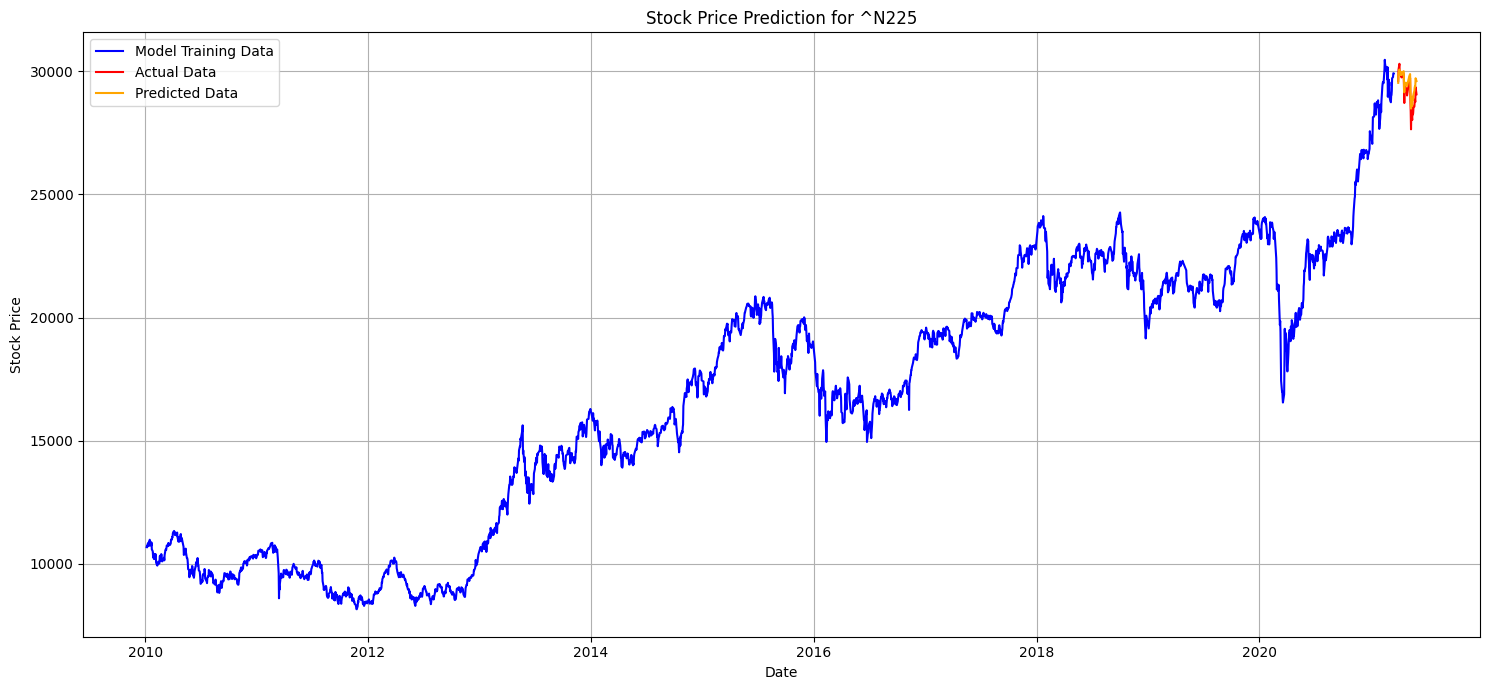

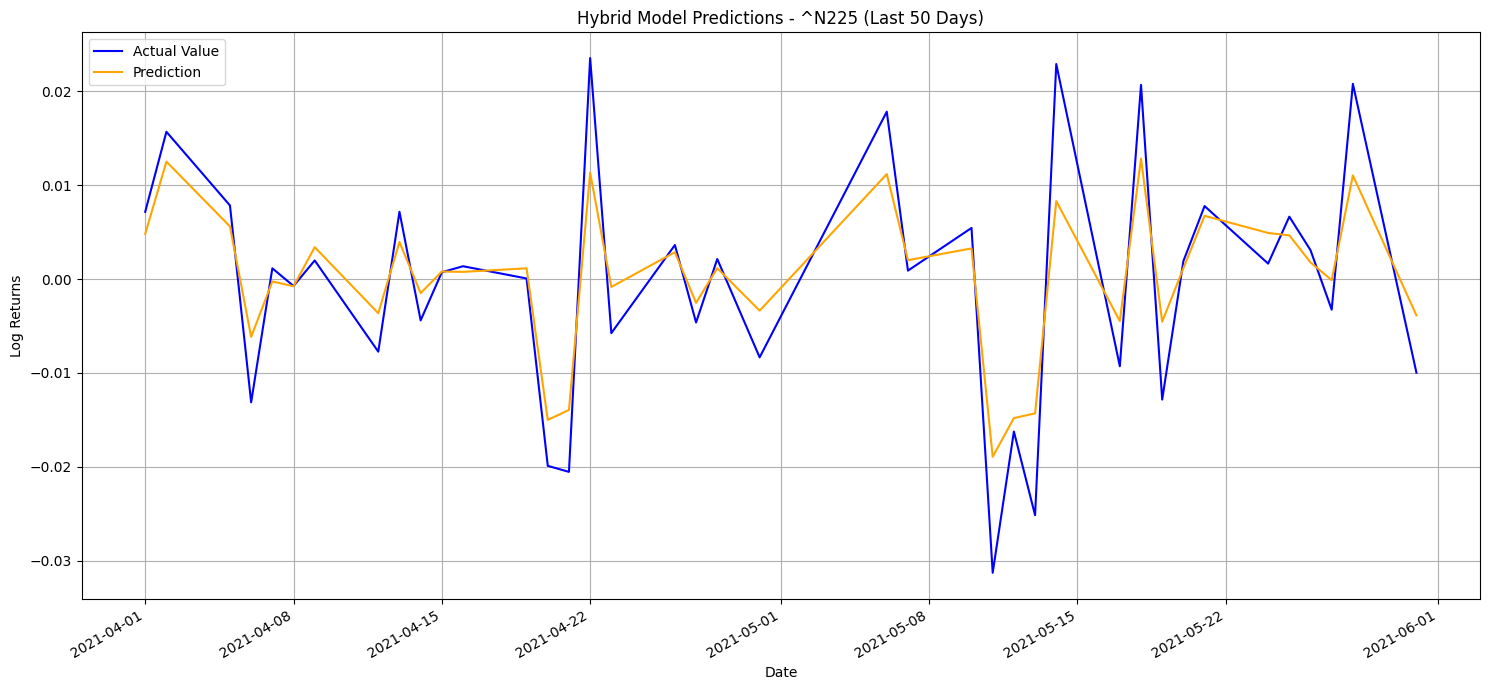


Performance Metrics for ^N225:
MSE: 0.000032
RMSE: 0.005623
MAE: 0.004220
R2: 0.803617
DIRECTION_ACCURACY: 0.868421
MAPE: 91.265265
Direction Accuracy (Last 50 days): 0.8684

Price Prediction Metrics for ^N225:
Price MSE: 144339.28
Price RMSE: 379.92
Price MAE: 308.53
Price R2: 0.6666


In [8]:
def analyze_different_stocks(model, stock_symbols, start_date='2010-01-01', end_date='2024-01-01'):
    """
    Makes predictions and visualizes results for different stocks.
    """
    for symbol in stock_symbols:
        print(f"\nAnalyzing {symbol}...")
        
        # Download stock data
        stock_data = yf.download(symbol, start=start_date, end=end_date)
        if len(stock_data) == 0:
            print(f"No data found for {symbol}")
            continue
            
        # Calculate log returns
        stock_data['Log_Returns'] = np.log(stock_data['Close']/stock_data['Close'].shift(1))
        stock_data = stock_data.dropna()
        
        # Train-test split
        train_size = int(len(stock_data) * 0.8)
        train_data = stock_data[:train_size]
        test_data = stock_data[train_size:]
        
        # Make predictions
        predictions = model.predict(test_data['Log_Returns'])
        
        # Prepare test data
        test_values = test_data['Log_Returns'].values[model.seq_length:model.seq_length+len(predictions)]
        
        # Convert to prices
        initial_price = test_data['Close'].iloc[model.seq_length]
        actual_prices = convert_returns_to_prices(initial_price, test_values)
        predicted_prices = convert_returns_to_prices(initial_price, predictions)
        
        # 1. Long-term price graph
        plt.figure(figsize=(15, 7))
        plt.plot(train_data.index, train_data['Close'], 
                label='Model Training Data', color='blue')
        
        test_dates = test_data.index[model.seq_length:model.seq_length+len(predictions)]
        plt.plot(test_dates, actual_prices[1:], 
                label='Actual Data', color='red')
        plt.plot(test_dates, predicted_prices[1:], 
                label='Predicted Data', color='orange')
        
        plt.title(f'Stock Price Prediction for {symbol}')
        plt.xlabel('Date')
        plt.ylabel('Stock Price')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # 2. Short-term return graph (last 50 days)
        plt.figure(figsize=(15, 7))
        last_50_days = slice(-50, None)
        
        short_term_dates = test_dates[last_50_days]
        short_term_actual = test_values[last_50_days]
        short_term_pred = predictions[last_50_days]
        
        plt.plot(short_term_dates, short_term_actual, 
                label='Actual Value', color='blue')
        plt.plot(short_term_dates, short_term_pred, 
                label='Prediction', color='orange')
        
        plt.title(f'Hybrid Model Predictions - {symbol} (Last 50 Days)')
        plt.xlabel('Date')
        plt.ylabel('Log Returns')
        plt.legend()
        plt.grid(True)
        plt.gcf().autofmt_xdate()
        plt.tight_layout()
        plt.show()
        
        # General performance metrics
        results = model.evaluate(test_values, predictions)
        print(f"\nPerformance Metrics for {symbol}:")
        for metric, value in results.items():
            print(f"{metric.upper()}: {value:.6f}")
        
        # Direction prediction accuracy (for the last 50 days)
        true_dir = np.sign(np.diff(short_term_actual))
        pred_dir = np.sign(np.diff(short_term_pred))
        direction_accuracy = np.mean(true_dir == pred_dir)
        print(f"Direction Accuracy (Last 50 days): {direction_accuracy:.4f}")
        
        # Price-based metrics
        price_mse = mean_squared_error(actual_prices[1:], predicted_prices[1:])
        price_rmse = np.sqrt(price_mse)
        price_mae = mean_absolute_error(actual_prices[1:], predicted_prices[1:])
        price_r2 = r2_score(actual_prices[1:], predicted_prices[1:])
        
        print(f"\nPrice Prediction Metrics for {symbol}:")
        print(f"Price MSE: {price_mse:.2f}")
        print(f"Price RMSE: {price_rmse:.2f}")
        print(f"Price MAE: {price_mae:.2f}")
        print(f"Price R2: {price_r2:.4f}")

# List of stocks to analyze
stock_symbols = [
    'AAPL',    # Apple
    'MSFT',    # Microsoft
    'GOOGL',   # Google
    'AMZN',    # Amazon
    '^DJI',    # Dow Jones Industrial Average
    '^IXIC',   # NASDAQ Composite
    '^FTSE',   # FTSE 100
    '^N225'    # Nikkei 225
]

# Run the analysis
analyze_different_stocks(model, stock_symbols)


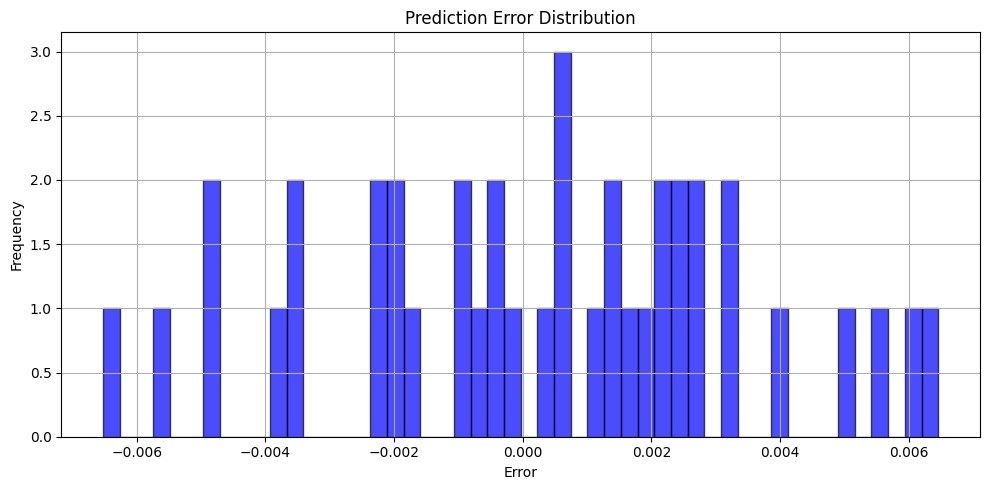

<Figure size 1000x500 with 0 Axes>

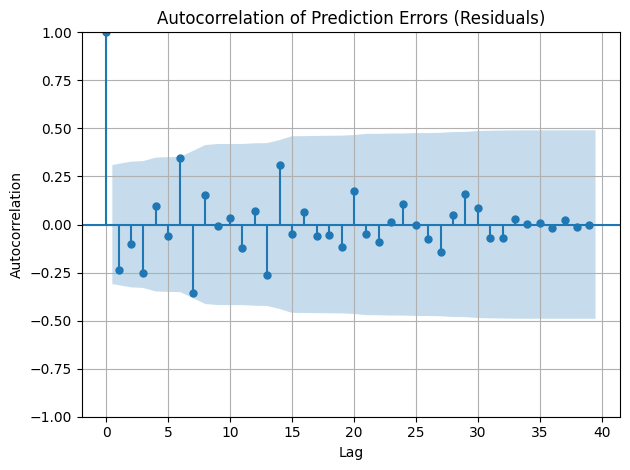


Residuals Analysis:
Mean of Residuals: 0.000303
Standard Deviation of Residuals: 0.003163
Min Residual: -0.006525
Max Residual: 0.006461


In [9]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np

# Function to analyze errors and residuals
def analyze_errors(test_values, predictions):
    # Calculate errors
    errors = test_values - predictions
    
    # Ensure the number of lags is valid
    max_lags = min(40, len(errors) - 1)  # Use the smaller of 40 or the available data length

    # Plot Prediction Error Distribution
    plt.figure(figsize=(10, 5))
    plt.hist(errors, bins=50, alpha=0.7, color='blue', edgecolor='black')
    plt.title('Prediction Error Distribution')
    plt.xlabel('Error')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Residuals Analysis using Autocorrelation
    plt.figure(figsize=(10, 5))
    sm.graphics.tsa.plot_acf(errors, lags=max_lags, alpha=0.05)
    plt.title('Autocorrelation of Prediction Errors (Residuals)')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Print residual statistics
    print("\nResiduals Analysis:")
    print(f"Mean of Residuals: {np.mean(errors):.6f}")
    print(f"Standard Deviation of Residuals: {np.std(errors):.6f}")
    print(f"Min Residual: {np.min(errors):.6f}")
    print(f"Max Residual: {np.max(errors):.6f}")

# Call the function after making predictions
analyze_errors(test_values, predictions)
